# Rekomputasi Order MVAR per Subjek (untuk `mvar_order_analysis.png`)

Menghitung ulang `VAR.select_order` (kriteria AIC) untuk seluruh 675 trial (15 subjek x 3 sesi x 15 trial), karena nilai order per-subjek yang dipakai pada `mvar_order_analysis.png` yang lama hanya pernah ada di memori kernel notebook saat itu dan tidak pernah disimpan ke disk (subjek S15 hilang dari chart lama akibat ini).

**Catatan penting:** ini HANYA menghitung ulang pemilihan order MVAR untuk keperluan gambar ini. Tidak menyentuh atau menimpa matriks PDC yang sudah ada di `new_data/02_pdc/output/pdc_matrices/` -- itu sudah benar dan tidak diubah.

Setiap sel di bawah memproses SATU sesi (15 trial, ~5-6 menit). Total 45 sesi, estimasi ~4-5 jam. Progress tersimpan ke `pdc_order_metadata.json` setelah setiap sesi selesai -- jadi kalau notebook ini dijalankan lewat papermill, file tersebut (dan file `.ipynb` ini sendiri) bisa dibuka kapan saja untuk melihat progres terakhir tanpa harus menunggu semuanya selesai.


In [1]:
import os
import json
import time
import numpy as np
from statsmodels.tsa.api import VAR
import warnings
warnings.filterwarnings('ignore')

INPUT_DIR = r'D:\Skripsi\new_data\00_preprocessing\output\preprocessed_eeg'
OUTPUT_DIR = r'D:\Skripsi\new_data\02_pdc\output'
META_PATH = os.path.join(OUTPUT_DIR, 'pdc_order_metadata.json')
PDC_MAX_ORDER = 15
PDC_MIN_ORDER = 3

def fit_order_only(data, max_order=15, min_order=3):
    """Same order-selection logic as fit_mvar() in 02_pdc_analysis.ipynb,
    but skips building coefficients / PDC -- we only need the AIC order here."""
    model = VAR(data)
    try:
        order_result = model.select_order(maxlags=max_order)
        optimal_order = order_result.aic
        optimal_order = max(optimal_order, min_order)
    except Exception:
        optimal_order = 5
    return optimal_order

def save_metadata():
    """Atomic write: dump to a temp file first, then swap it in.
    Kalau kernel mati di tengah proses tulis, file lama tetap utuh
    (bukan JSON terpotong seperti sebelumnya)."""
    tmp = META_PATH + '.tmp'
    with open(tmp, 'w', encoding='utf-8') as f:
        json.dump(metadata, f, indent=2)
        f.flush()
        os.fsync(f.fileno())
    os.replace(tmp, META_PATH)

def load_metadata():
    """Baca metadata yang sudah ada; kalau file-nya korup (mis. hasil
    interupsi lama), sisihkan ke .corrupt.bak dan mulai dari kosong
    supaya notebook tidak gagal di sel setup."""
    if not os.path.exists(META_PATH):
        return {'fs': 100, 'subjects': {}}
    try:
        with open(META_PATH, encoding='utf-8') as f:
            meta = json.load(f)
        n = sum(len(s) for s in meta.get('subjects', {}).values())
        print(f'Resuming from existing {META_PATH} ({n}/45 sessions done)')
        return meta
    except json.JSONDecodeError as e:
        bak = META_PATH + '.corrupt.bak'
        os.replace(META_PATH, bak)
        print(f'WARNING: {META_PATH} korup ({e}); dipindah ke {bak}, mulai dari nol.')
        return {'fs': 100, 'subjects': {}}

metadata = load_metadata()

def process_session(subject, session):
    if session in metadata['subjects'].get(subject, {}):
        print(f'  [SKIP already done] {subject}/{session}')
        return
    session_dir = os.path.join(INPUT_DIR, subject, session)
    if not os.path.isdir(session_dir):
        print(f'  [MISSING] {session_dir} -- dilewati')
        return
    trial_files = sorted(f for f in os.listdir(session_dir) if f.endswith('.npy'))
    orders = []
    t0 = time.time()
    for tf in trial_files:
        eeg = np.load(os.path.join(session_dir, tf))
        data = eeg.T
        order = fit_order_only(data, PDC_MAX_ORDER, PDC_MIN_ORDER)
        orders.append(int(order))
        print(f'    {tf}: order={order} ({time.time()-t0:.0f}s elapsed)', flush=True)
    elapsed = time.time() - t0
    metadata['subjects'].setdefault(subject, {})[session] = {
        'n_trials': len(orders), 'mean_order': float(np.mean(orders)),
        'orders': orders, 'time_s': round(elapsed, 1),
    }
    save_metadata()
    print(f'  DONE {subject}/{session}: {len(orders)} trials, '
          f'mean_order={np.mean(orders):.2f}, {elapsed:.0f}s -> saved to {META_PATH}')

print('Setup OK. META_PATH =', META_PATH)


Resuming from existing D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json (9/45 sessions done)
Setup OK. META_PATH = D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [2]:
process_session('subject_01', 'session_20131027')


  [SKIP already done] subject_01/session_20131027


In [3]:
process_session('subject_01', 'session_20131030')


  [SKIP already done] subject_01/session_20131030


In [4]:
process_session('subject_01', 'session_20131107')


  [SKIP already done] subject_01/session_20131107


In [5]:
process_session('subject_02', 'session_20140404')


  [SKIP already done] subject_02/session_20140404


In [6]:
process_session('subject_02', 'session_20140413')


  [SKIP already done] subject_02/session_20140413


In [7]:
process_session('subject_02', 'session_20140419')


  [SKIP already done] subject_02/session_20140419


In [8]:
process_session('subject_03', 'session_20140603')


  [SKIP already done] subject_03/session_20140603


In [9]:
process_session('subject_03', 'session_20140611')


  [SKIP already done] subject_03/session_20140611


In [10]:
process_session('subject_03', 'session_20140629')


  [SKIP already done] subject_03/session_20140629


In [11]:
process_session('subject_04', 'session_20140621')


    trial_01.npy: order=15 (21s elapsed)
    trial_02.npy: order=15 (45s elapsed)
    trial_03.npy: order=15 (64s elapsed)
    trial_04.npy: order=14 (84s elapsed)
    trial_05.npy: order=14 (96s elapsed)
    trial_06.npy: order=15 (108s elapsed)
    trial_07.npy: order=14 (126s elapsed)
    trial_08.npy: order=15 (145s elapsed)
    trial_09.npy: order=14 (168s elapsed)
    trial_10.npy: order=14 (188s elapsed)
    trial_11.npy: order=15 (209s elapsed)
    trial_12.npy: order=15 (230s elapsed)
    trial_13.npy: order=14 (251s elapsed)
    trial_14.npy: order=15 (270s elapsed)
    trial_15.npy: order=15 (284s elapsed)
  DONE subject_04/session_20140621: 15 trials, mean_order=14.60, 284s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [12]:
process_session('subject_04', 'session_20140702')


    trial_01.npy: order=15 (21s elapsed)
    trial_02.npy: order=15 (41s elapsed)
    trial_03.npy: order=15 (58s elapsed)
    trial_04.npy: order=15 (76s elapsed)
    trial_05.npy: order=14 (89s elapsed)
    trial_06.npy: order=15 (101s elapsed)
    trial_07.npy: order=15 (118s elapsed)
    trial_08.npy: order=14 (134s elapsed)
    trial_09.npy: order=15 (152s elapsed)
    trial_10.npy: order=15 (168s elapsed)
    trial_11.npy: order=15 (186s elapsed)
    trial_12.npy: order=15 (204s elapsed)
    trial_13.npy: order=15 (220s elapsed)
    trial_14.npy: order=15 (237s elapsed)
    trial_15.npy: order=15 (251s elapsed)
  DONE subject_04/session_20140702: 15 trials, mean_order=14.87, 251s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [13]:
process_session('subject_04', 'session_20140705')


    trial_01.npy: order=15 (16s elapsed)
    trial_02.npy: order=15 (32s elapsed)
    trial_03.npy: order=15 (47s elapsed)
    trial_04.npy: order=15 (62s elapsed)
    trial_05.npy: order=15 (76s elapsed)
    trial_06.npy: order=15 (90s elapsed)
    trial_07.npy: order=15 (107s elapsed)
    trial_08.npy: order=15 (122s elapsed)
    trial_09.npy: order=15 (142s elapsed)
    trial_10.npy: order=15 (158s elapsed)
    trial_11.npy: order=15 (172s elapsed)
    trial_12.npy: order=14 (190s elapsed)
    trial_13.npy: order=14 (209s elapsed)
    trial_14.npy: order=15 (229s elapsed)
    trial_15.npy: order=15 (247s elapsed)
  DONE subject_04/session_20140705: 15 trials, mean_order=14.87, 247s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [14]:
process_session('subject_05', 'session_20140411')


    trial_01.npy: order=15 (19s elapsed)
    trial_02.npy: order=14 (36s elapsed)
    trial_03.npy: order=14 (52s elapsed)
    trial_04.npy: order=14 (71s elapsed)
    trial_05.npy: order=14 (86s elapsed)
    trial_06.npy: order=14 (102s elapsed)
    trial_07.npy: order=15 (119s elapsed)
    trial_08.npy: order=15 (136s elapsed)
    trial_09.npy: order=15 (157s elapsed)
    trial_10.npy: order=14 (175s elapsed)
    trial_11.npy: order=15 (193s elapsed)
    trial_12.npy: order=15 (211s elapsed)
    trial_13.npy: order=14 (229s elapsed)
    trial_14.npy: order=15 (247s elapsed)
    trial_15.npy: order=14 (261s elapsed)
  DONE subject_05/session_20140411: 15 trials, mean_order=14.47, 261s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [15]:
process_session('subject_05', 'session_20140418')


    trial_01.npy: order=14 (13s elapsed)
    trial_02.npy: order=14 (28s elapsed)
    trial_03.npy: order=14 (44s elapsed)
    trial_04.npy: order=15 (62s elapsed)
    trial_05.npy: order=14 (76s elapsed)
    trial_06.npy: order=14 (91s elapsed)
    trial_07.npy: order=14 (108s elapsed)
    trial_08.npy: order=15 (124s elapsed)
    trial_09.npy: order=15 (143s elapsed)
    trial_10.npy: order=14 (161s elapsed)
    trial_11.npy: order=15 (178s elapsed)
    trial_12.npy: order=15 (195s elapsed)
    trial_13.npy: order=15 (213s elapsed)
    trial_14.npy: order=15 (231s elapsed)
    trial_15.npy: order=15 (244s elapsed)
  DONE subject_05/session_20140418: 15 trials, mean_order=14.53, 244s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [16]:
process_session('subject_05', 'session_20140506')


    trial_01.npy: order=15 (16s elapsed)
    trial_02.npy: order=15 (34s elapsed)
    trial_03.npy: order=14 (49s elapsed)
    trial_04.npy: order=14 (67s elapsed)
    trial_05.npy: order=15 (82s elapsed)
    trial_06.npy: order=15 (98s elapsed)
    trial_07.npy: order=15 (116s elapsed)
    trial_08.npy: order=15 (133s elapsed)
    trial_09.npy: order=15 (154s elapsed)
    trial_10.npy: order=15 (171s elapsed)
    trial_11.npy: order=15 (189s elapsed)
    trial_12.npy: order=15 (207s elapsed)
    trial_13.npy: order=15 (225s elapsed)
    trial_14.npy: order=15 (242s elapsed)
    trial_15.npy: order=15 (258s elapsed)
  DONE subject_05/session_20140506: 15 trials, mean_order=14.87, 258s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [17]:
process_session('subject_06', 'session_20130712')


    trial_01.npy: order=15 (18s elapsed)
    trial_02.npy: order=14 (36s elapsed)
    trial_03.npy: order=14 (47s elapsed)
    trial_04.npy: order=14 (64s elapsed)
    trial_05.npy: order=14 (79s elapsed)
    trial_06.npy: order=14 (94s elapsed)
    trial_07.npy: order=14 (112s elapsed)
    trial_08.npy: order=14 (129s elapsed)
    trial_09.npy: order=14 (149s elapsed)
    trial_10.npy: order=14 (168s elapsed)
    trial_11.npy: order=15 (186s elapsed)
    trial_12.npy: order=14 (204s elapsed)
    trial_13.npy: order=14 (221s elapsed)
    trial_14.npy: order=14 (239s elapsed)
    trial_15.npy: order=14 (255s elapsed)
  DONE subject_06/session_20130712: 15 trials, mean_order=14.13, 255s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [18]:
process_session('subject_06', 'session_20131016')


    trial_01.npy: order=15 (18s elapsed)
    trial_02.npy: order=15 (36s elapsed)
    trial_03.npy: order=14 (51s elapsed)
    trial_04.npy: order=14 (70s elapsed)
    trial_05.npy: order=14 (84s elapsed)
    trial_06.npy: order=14 (100s elapsed)
    trial_07.npy: order=14 (114s elapsed)
    trial_08.npy: order=15 (129s elapsed)
    trial_09.npy: order=15 (147s elapsed)
    trial_10.npy: order=14 (163s elapsed)
    trial_11.npy: order=15 (179s elapsed)
    trial_12.npy: order=15 (195s elapsed)
    trial_13.npy: order=15 (211s elapsed)
    trial_14.npy: order=15 (227s elapsed)
    trial_15.npy: order=14 (241s elapsed)
  DONE subject_06/session_20131016: 15 trials, mean_order=14.53, 241s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [19]:
process_session('subject_06', 'session_20131113')


    trial_01.npy: order=14 (17s elapsed)
    trial_02.npy: order=14 (33s elapsed)
    trial_03.npy: order=14 (48s elapsed)
    trial_04.npy: order=14 (64s elapsed)
    trial_05.npy: order=14 (78s elapsed)
    trial_06.npy: order=14 (92s elapsed)
    trial_07.npy: order=14 (108s elapsed)
    trial_08.npy: order=14 (122s elapsed)
    trial_09.npy: order=14 (140s elapsed)
    trial_10.npy: order=14 (156s elapsed)
    trial_11.npy: order=15 (172s elapsed)
    trial_12.npy: order=14 (188s elapsed)
    trial_13.npy: order=14 (204s elapsed)
    trial_14.npy: order=14 (220s elapsed)
    trial_15.npy: order=14 (235s elapsed)
  DONE subject_06/session_20131113: 15 trials, mean_order=14.07, 235s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [20]:
process_session('subject_07', 'session_20131027')


    trial_01.npy: order=14 (16s elapsed)
    trial_02.npy: order=15 (32s elapsed)
    trial_03.npy: order=14 (46s elapsed)
    trial_04.npy: order=14 (63s elapsed)
    trial_05.npy: order=14 (76s elapsed)
    trial_06.npy: order=15 (90s elapsed)
    trial_07.npy: order=14 (106s elapsed)
    trial_08.npy: order=15 (121s elapsed)
    trial_09.npy: order=15 (139s elapsed)
    trial_10.npy: order=15 (155s elapsed)
    trial_11.npy: order=14 (172s elapsed)
    trial_12.npy: order=15 (189s elapsed)
    trial_13.npy: order=14 (208s elapsed)
    trial_14.npy: order=15 (225s elapsed)
    trial_15.npy: order=15 (239s elapsed)
  DONE subject_07/session_20131027: 15 trials, mean_order=14.53, 239s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [21]:
process_session('subject_07', 'session_20131030')


    trial_01.npy: order=14 (16s elapsed)
    trial_02.npy: order=14 (33s elapsed)
    trial_03.npy: order=14 (47s elapsed)
    trial_04.npy: order=14 (64s elapsed)
    trial_05.npy: order=15 (78s elapsed)
    trial_06.npy: order=14 (92s elapsed)
    trial_07.npy: order=14 (109s elapsed)
    trial_08.npy: order=15 (124s elapsed)
    trial_09.npy: order=15 (142s elapsed)
    trial_10.npy: order=15 (159s elapsed)
    trial_11.npy: order=15 (175s elapsed)
    trial_12.npy: order=14 (191s elapsed)
    trial_13.npy: order=15 (207s elapsed)
    trial_14.npy: order=14 (226s elapsed)
    trial_15.npy: order=15 (243s elapsed)
  DONE subject_07/session_20131030: 15 trials, mean_order=14.47, 243s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [22]:
process_session('subject_07', 'session_20131106')


    trial_01.npy: order=14 (18s elapsed)
    trial_02.npy: order=14 (34s elapsed)
    trial_03.npy: order=14 (49s elapsed)
    trial_04.npy: order=14 (66s elapsed)
    trial_05.npy: order=15 (79s elapsed)
    trial_06.npy: order=15 (93s elapsed)
    trial_07.npy: order=15 (110s elapsed)
    trial_08.npy: order=14 (125s elapsed)
    trial_09.npy: order=15 (143s elapsed)
    trial_10.npy: order=15 (159s elapsed)
    trial_11.npy: order=15 (175s elapsed)
    trial_12.npy: order=15 (189s elapsed)
    trial_13.npy: order=15 (202s elapsed)
    trial_14.npy: order=15 (214s elapsed)
    trial_15.npy: order=14 (225s elapsed)
  DONE subject_07/session_20131106: 15 trials, mean_order=14.60, 225s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [23]:
process_session('subject_08', 'session_20140511')


    trial_01.npy: order=15 (18s elapsed)
    trial_02.npy: order=14 (37s elapsed)
    trial_03.npy: order=14 (53s elapsed)
    trial_04.npy: order=14 (71s elapsed)
    trial_05.npy: order=14 (84s elapsed)
    trial_06.npy: order=14 (100s elapsed)
    trial_07.npy: order=14 (113s elapsed)
    trial_08.npy: order=14 (124s elapsed)
    trial_09.npy: order=15 (140s elapsed)
    trial_10.npy: order=15 (158s elapsed)
    trial_11.npy: order=15 (176s elapsed)
    trial_12.npy: order=14 (194s elapsed)
    trial_13.npy: order=14 (213s elapsed)
    trial_14.npy: order=14 (231s elapsed)
    trial_15.npy: order=15 (247s elapsed)
  DONE subject_08/session_20140511: 15 trials, mean_order=14.33, 247s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [24]:
process_session('subject_08', 'session_20140514')


    trial_01.npy: order=15 (18s elapsed)
    trial_02.npy: order=14 (36s elapsed)
    trial_03.npy: order=14 (52s elapsed)
    trial_04.npy: order=14 (69s elapsed)
    trial_05.npy: order=14 (84s elapsed)
    trial_06.npy: order=14 (99s elapsed)
    trial_07.npy: order=14 (117s elapsed)
    trial_08.npy: order=14 (135s elapsed)
    trial_09.npy: order=14 (155s elapsed)
    trial_10.npy: order=15 (173s elapsed)
    trial_11.npy: order=14 (191s elapsed)
    trial_12.npy: order=14 (209s elapsed)
    trial_13.npy: order=14 (227s elapsed)
    trial_14.npy: order=14 (245s elapsed)
    trial_15.npy: order=15 (262s elapsed)
  DONE subject_08/session_20140514: 15 trials, mean_order=14.20, 262s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [25]:
process_session('subject_08', 'session_20140521')


    trial_01.npy: order=15 (18s elapsed)
    trial_02.npy: order=15 (36s elapsed)
    trial_03.npy: order=15 (52s elapsed)
    trial_04.npy: order=15 (71s elapsed)
    trial_05.npy: order=14 (86s elapsed)
    trial_06.npy: order=14 (102s elapsed)
    trial_07.npy: order=15 (119s elapsed)
    trial_08.npy: order=15 (136s elapsed)
    trial_09.npy: order=15 (155s elapsed)
    trial_10.npy: order=15 (173s elapsed)
    trial_11.npy: order=15 (190s elapsed)
    trial_12.npy: order=14 (208s elapsed)
    trial_13.npy: order=15 (225s elapsed)
    trial_14.npy: order=15 (244s elapsed)
    trial_15.npy: order=15 (260s elapsed)
  DONE subject_08/session_20140521: 15 trials, mean_order=14.80, 260s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [26]:
process_session('subject_09', 'session_20140620')


    trial_01.npy: order=15 (17s elapsed)
    trial_02.npy: order=15 (32s elapsed)
    trial_03.npy: order=15 (47s elapsed)
    trial_04.npy: order=15 (63s elapsed)
    trial_05.npy: order=14 (75s elapsed)
    trial_06.npy: order=15 (88s elapsed)
    trial_07.npy: order=15 (103s elapsed)
    trial_08.npy: order=15 (118s elapsed)
    trial_09.npy: order=15 (134s elapsed)
    trial_10.npy: order=15 (149s elapsed)
    trial_11.npy: order=15 (165s elapsed)
    trial_12.npy: order=15 (181s elapsed)
    trial_13.npy: order=15 (198s elapsed)
    trial_14.npy: order=15 (214s elapsed)
    trial_15.npy: order=15 (229s elapsed)
  DONE subject_09/session_20140620: 15 trials, mean_order=14.93, 229s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [27]:
process_session('subject_09', 'session_20140627')


    trial_01.npy: order=15 (17s elapsed)
    trial_02.npy: order=15 (34s elapsed)
    trial_03.npy: order=15 (49s elapsed)
    trial_04.npy: order=15 (66s elapsed)
    trial_05.npy: order=15 (80s elapsed)
    trial_06.npy: order=14 (94s elapsed)
    trial_07.npy: order=15 (112s elapsed)
    trial_08.npy: order=15 (129s elapsed)
    trial_09.npy: order=15 (147s elapsed)
    trial_10.npy: order=15 (163s elapsed)
    trial_11.npy: order=15 (180s elapsed)
    trial_12.npy: order=15 (196s elapsed)
    trial_13.npy: order=15 (212s elapsed)
    trial_14.npy: order=15 (229s elapsed)
    trial_15.npy: order=15 (243s elapsed)
  DONE subject_09/session_20140627: 15 trials, mean_order=14.93, 243s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [28]:
process_session('subject_09', 'session_20140704')


    trial_01.npy: order=15 (15s elapsed)
    trial_02.npy: order=15 (30s elapsed)
    trial_03.npy: order=14 (44s elapsed)
    trial_04.npy: order=15 (59s elapsed)
    trial_05.npy: order=15 (72s elapsed)
    trial_06.npy: order=14 (85s elapsed)
    trial_07.npy: order=15 (100s elapsed)
    trial_08.npy: order=14 (115s elapsed)
    trial_09.npy: order=15 (131s elapsed)
    trial_10.npy: order=14 (146s elapsed)
    trial_11.npy: order=14 (161s elapsed)
    trial_12.npy: order=15 (176s elapsed)
    trial_13.npy: order=15 (191s elapsed)
    trial_14.npy: order=15 (207s elapsed)
    trial_15.npy: order=15 (220s elapsed)
  DONE subject_09/session_20140704: 15 trials, mean_order=14.67, 220s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [29]:
process_session('subject_10', 'session_20131130')


    trial_01.npy: order=14 (15s elapsed)
    trial_02.npy: order=14 (30s elapsed)
    trial_03.npy: order=14 (44s elapsed)
    trial_04.npy: order=15 (59s elapsed)
    trial_05.npy: order=14 (72s elapsed)
    trial_06.npy: order=14 (85s elapsed)
    trial_07.npy: order=14 (100s elapsed)
    trial_08.npy: order=14 (114s elapsed)
    trial_09.npy: order=15 (131s elapsed)
    trial_10.npy: order=14 (146s elapsed)
    trial_11.npy: order=14 (161s elapsed)
    trial_12.npy: order=14 (176s elapsed)
    trial_13.npy: order=14 (191s elapsed)
    trial_14.npy: order=14 (207s elapsed)
    trial_15.npy: order=14 (220s elapsed)
  DONE subject_10/session_20131130: 15 trials, mean_order=14.13, 220s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [30]:
process_session('subject_10', 'session_20131204')


    trial_01.npy: order=14 (15s elapsed)
    trial_02.npy: order=14 (30s elapsed)
    trial_03.npy: order=14 (44s elapsed)
    trial_04.npy: order=14 (59s elapsed)
    trial_05.npy: order=14 (72s elapsed)
    trial_06.npy: order=14 (85s elapsed)
    trial_07.npy: order=14 (102s elapsed)
    trial_08.npy: order=14 (116s elapsed)
    trial_09.npy: order=15 (133s elapsed)
    trial_10.npy: order=15 (147s elapsed)
    trial_11.npy: order=14 (164s elapsed)
    trial_12.npy: order=14 (179s elapsed)
    trial_13.npy: order=14 (195s elapsed)
    trial_14.npy: order=15 (210s elapsed)
    trial_15.npy: order=15 (225s elapsed)
  DONE subject_10/session_20131204: 15 trials, mean_order=14.27, 225s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [31]:
process_session('subject_10', 'session_20131211')


    trial_01.npy: order=14 (15s elapsed)
    trial_02.npy: order=14 (31s elapsed)
    trial_03.npy: order=14 (44s elapsed)
    trial_04.npy: order=15 (60s elapsed)
    trial_05.npy: order=14 (73s elapsed)
    trial_06.npy: order=14 (87s elapsed)
    trial_07.npy: order=15 (103s elapsed)
    trial_08.npy: order=14 (117s elapsed)
    trial_09.npy: order=14 (133s elapsed)
    trial_10.npy: order=14 (148s elapsed)
    trial_11.npy: order=14 (163s elapsed)
    trial_12.npy: order=14 (179s elapsed)
    trial_13.npy: order=14 (196s elapsed)
    trial_14.npy: order=14 (214s elapsed)
    trial_15.npy: order=14 (229s elapsed)
  DONE subject_10/session_20131211: 15 trials, mean_order=14.13, 229s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [32]:
process_session('subject_11', 'session_20140618')


    trial_01.npy: order=14 (16s elapsed)
    trial_02.npy: order=14 (33s elapsed)
    trial_03.npy: order=14 (47s elapsed)
    trial_04.npy: order=14 (68s elapsed)
    trial_05.npy: order=14 (84s elapsed)
    trial_06.npy: order=14 (99s elapsed)
    trial_07.npy: order=14 (117s elapsed)
    trial_08.npy: order=14 (134s elapsed)
    trial_09.npy: order=14 (154s elapsed)
    trial_10.npy: order=15 (170s elapsed)
    trial_11.npy: order=14 (188s elapsed)
    trial_12.npy: order=14 (204s elapsed)
    trial_13.npy: order=14 (221s elapsed)
    trial_14.npy: order=15 (241s elapsed)
    trial_15.npy: order=15 (259s elapsed)
  DONE subject_11/session_20140618: 15 trials, mean_order=14.20, 259s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [33]:
process_session('subject_11', 'session_20140625')


    trial_01.npy: order=14 (19s elapsed)
    trial_02.npy: order=14 (34s elapsed)
    trial_03.npy: order=14 (47s elapsed)
    trial_04.npy: order=14 (62s elapsed)
    trial_05.npy: order=14 (74s elapsed)
    trial_06.npy: order=15 (87s elapsed)
    trial_07.npy: order=15 (102s elapsed)
    trial_08.npy: order=15 (116s elapsed)
    trial_09.npy: order=15 (132s elapsed)
    trial_10.npy: order=14 (149s elapsed)
    trial_11.npy: order=14 (166s elapsed)
    trial_12.npy: order=15 (182s elapsed)
    trial_13.npy: order=15 (198s elapsed)
    trial_14.npy: order=15 (222s elapsed)
    trial_15.npy: order=15 (239s elapsed)
  DONE subject_11/session_20140625: 15 trials, mean_order=14.53, 239s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [34]:
process_session('subject_11', 'session_20140630')


    trial_01.npy: order=14 (19s elapsed)
    trial_02.npy: order=14 (36s elapsed)
    trial_03.npy: order=14 (52s elapsed)
    trial_04.npy: order=15 (70s elapsed)
    trial_05.npy: order=14 (85s elapsed)
    trial_06.npy: order=14 (99s elapsed)
    trial_07.npy: order=15 (111s elapsed)
    trial_08.npy: order=15 (122s elapsed)
    trial_09.npy: order=15 (135s elapsed)
    trial_10.npy: order=15 (147s elapsed)
    trial_11.npy: order=14 (159s elapsed)
    trial_12.npy: order=15 (170s elapsed)
    trial_13.npy: order=14 (182s elapsed)
    trial_14.npy: order=15 (194s elapsed)
    trial_15.npy: order=15 (204s elapsed)
  DONE subject_11/session_20140630: 15 trials, mean_order=14.53, 204s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [35]:
process_session('subject_12', 'session_20131127')


    trial_01.npy: order=15 (12s elapsed)
    trial_02.npy: order=15 (24s elapsed)
    trial_03.npy: order=15 (34s elapsed)
    trial_04.npy: order=15 (45s elapsed)
    trial_05.npy: order=15 (55s elapsed)
    trial_06.npy: order=15 (65s elapsed)
    trial_07.npy: order=15 (76s elapsed)
    trial_08.npy: order=15 (87s elapsed)
    trial_09.npy: order=15 (100s elapsed)
    trial_10.npy: order=15 (111s elapsed)
    trial_11.npy: order=15 (123s elapsed)
    trial_12.npy: order=15 (134s elapsed)
    trial_13.npy: order=15 (147s elapsed)
    trial_14.npy: order=15 (159s elapsed)
    trial_15.npy: order=15 (170s elapsed)
  DONE subject_12/session_20131127: 15 trials, mean_order=15.00, 170s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [36]:
process_session('subject_12', 'session_20131201')


    trial_01.npy: order=14 (12s elapsed)
    trial_02.npy: order=14 (24s elapsed)
    trial_03.npy: order=14 (34s elapsed)
    trial_04.npy: order=15 (46s elapsed)
    trial_05.npy: order=14 (56s elapsed)
    trial_06.npy: order=15 (65s elapsed)
    trial_07.npy: order=14 (77s elapsed)
    trial_08.npy: order=15 (89s elapsed)
    trial_09.npy: order=15 (102s elapsed)
    trial_10.npy: order=15 (114s elapsed)
    trial_11.npy: order=15 (126s elapsed)
    trial_12.npy: order=15 (137s elapsed)
    trial_13.npy: order=15 (149s elapsed)
    trial_14.npy: order=15 (161s elapsed)
    trial_15.npy: order=15 (172s elapsed)
  DONE subject_12/session_20131201: 15 trials, mean_order=14.67, 172s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [37]:
process_session('subject_12', 'session_20131207')


    trial_01.npy: order=14 (12s elapsed)
    trial_02.npy: order=15 (24s elapsed)
    trial_03.npy: order=15 (34s elapsed)
    trial_04.npy: order=15 (46s elapsed)
    trial_05.npy: order=15 (55s elapsed)
    trial_06.npy: order=15 (65s elapsed)
    trial_07.npy: order=15 (77s elapsed)
    trial_08.npy: order=15 (87s elapsed)
    trial_09.npy: order=15 (100s elapsed)
    trial_10.npy: order=15 (118s elapsed)
    trial_11.npy: order=15 (136s elapsed)
    trial_12.npy: order=15 (149s elapsed)
    trial_13.npy: order=15 (161s elapsed)
    trial_14.npy: order=15 (173s elapsed)
    trial_15.npy: order=15 (183s elapsed)
  DONE subject_12/session_20131207: 15 trials, mean_order=14.93, 183s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [38]:
process_session('subject_13', 'session_20140527')


    trial_01.npy: order=15 (12s elapsed)
    trial_02.npy: order=14 (24s elapsed)
    trial_03.npy: order=14 (39s elapsed)
    trial_04.npy: order=14 (56s elapsed)
    trial_05.npy: order=14 (68s elapsed)
    trial_06.npy: order=15 (78s elapsed)
    trial_07.npy: order=14 (90s elapsed)
    trial_08.npy: order=14 (102s elapsed)
    trial_09.npy: order=15 (116s elapsed)
    trial_10.npy: order=15 (128s elapsed)
    trial_11.npy: order=15 (140s elapsed)
    trial_12.npy: order=14 (151s elapsed)
    trial_13.npy: order=15 (163s elapsed)
    trial_14.npy: order=15 (176s elapsed)
    trial_15.npy: order=14 (187s elapsed)
  DONE subject_13/session_20140527: 15 trials, mean_order=14.47, 187s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [39]:
process_session('subject_13', 'session_20140603')


    trial_01.npy: order=15 (14s elapsed)
    trial_02.npy: order=15 (31s elapsed)
    trial_03.npy: order=14 (45s elapsed)
    trial_04.npy: order=15 (62s elapsed)
    trial_05.npy: order=14 (75s elapsed)
    trial_06.npy: order=14 (87s elapsed)
    trial_07.npy: order=15 (105s elapsed)
    trial_08.npy: order=14 (119s elapsed)
    trial_09.npy: order=15 (138s elapsed)
    trial_10.npy: order=15 (157s elapsed)
    trial_11.npy: order=14 (184s elapsed)
    trial_12.npy: order=15 (207s elapsed)
    trial_13.npy: order=15 (236s elapsed)
    trial_14.npy: order=15 (251s elapsed)
    trial_15.npy: order=15 (284s elapsed)
  DONE subject_13/session_20140603: 15 trials, mean_order=14.67, 284s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [40]:
process_session('subject_13', 'session_20140610')


    trial_01.npy: order=15 (13s elapsed)
    trial_02.npy: order=15 (26s elapsed)
    trial_03.npy: order=15 (38s elapsed)
    trial_04.npy: order=15 (51s elapsed)
    trial_05.npy: order=14 (67s elapsed)
    trial_06.npy: order=14 (83s elapsed)
    trial_07.npy: order=15 (103s elapsed)
    trial_08.npy: order=14 (121s elapsed)
    trial_09.npy: order=15 (142s elapsed)
    trial_10.npy: order=15 (161s elapsed)
    trial_11.npy: order=15 (179s elapsed)
    trial_12.npy: order=15 (197s elapsed)
    trial_13.npy: order=14 (211s elapsed)
    trial_14.npy: order=15 (222s elapsed)
    trial_15.npy: order=15 (233s elapsed)
  DONE subject_13/session_20140610: 15 trials, mean_order=14.73, 233s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [41]:
process_session('subject_14', 'session_20140601')


    trial_01.npy: order=14 (12s elapsed)
    trial_02.npy: order=14 (23s elapsed)
    trial_03.npy: order=14 (34s elapsed)
    trial_04.npy: order=14 (50s elapsed)
    trial_05.npy: order=14 (65s elapsed)
    trial_06.npy: order=15 (79s elapsed)
    trial_07.npy: order=14 (94s elapsed)
    trial_08.npy: order=14 (111s elapsed)
    trial_09.npy: order=14 (131s elapsed)
    trial_10.npy: order=14 (149s elapsed)
    trial_11.npy: order=14 (168s elapsed)
    trial_12.npy: order=14 (186s elapsed)
    trial_13.npy: order=14 (203s elapsed)
    trial_14.npy: order=15 (222s elapsed)
    trial_15.npy: order=15 (236s elapsed)
  DONE subject_14/session_20140601: 15 trials, mean_order=14.20, 236s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [42]:
process_session('subject_14', 'session_20140615')


    trial_01.npy: order=14 (15s elapsed)
    trial_02.npy: order=14 (33s elapsed)
    trial_03.npy: order=14 (49s elapsed)
    trial_04.npy: order=14 (67s elapsed)
    trial_05.npy: order=14 (82s elapsed)
    trial_06.npy: order=14 (98s elapsed)
    trial_07.npy: order=14 (116s elapsed)
    trial_08.npy: order=14 (132s elapsed)
    trial_09.npy: order=14 (152s elapsed)
    trial_10.npy: order=14 (171s elapsed)
    trial_11.npy: order=14 (183s elapsed)
    trial_12.npy: order=14 (194s elapsed)
    trial_13.npy: order=14 (206s elapsed)
    trial_14.npy: order=14 (218s elapsed)
    trial_15.npy: order=15 (229s elapsed)
  DONE subject_14/session_20140615: 15 trials, mean_order=14.07, 229s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [43]:
process_session('subject_14', 'session_20140627')


    trial_01.npy: order=15 (12s elapsed)
    trial_02.npy: order=14 (24s elapsed)
    trial_03.npy: order=15 (34s elapsed)
    trial_04.npy: order=14 (46s elapsed)
    trial_05.npy: order=14 (56s elapsed)
    trial_06.npy: order=15 (66s elapsed)
    trial_07.npy: order=15 (78s elapsed)
    trial_08.npy: order=14 (92s elapsed)
    trial_09.npy: order=15 (108s elapsed)
    trial_10.npy: order=14 (127s elapsed)
    trial_11.npy: order=14 (146s elapsed)
    trial_12.npy: order=15 (165s elapsed)
    trial_13.npy: order=15 (183s elapsed)
    trial_14.npy: order=15 (201s elapsed)
    trial_15.npy: order=14 (217s elapsed)
  DONE subject_14/session_20140627: 15 trials, mean_order=14.53, 217s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [44]:
process_session('subject_15', 'session_20130709')


    trial_01.npy: order=15 (18s elapsed)
    trial_02.npy: order=14 (36s elapsed)
    trial_03.npy: order=14 (52s elapsed)
    trial_04.npy: order=15 (71s elapsed)
    trial_05.npy: order=14 (81s elapsed)
    trial_06.npy: order=14 (93s elapsed)
    trial_07.npy: order=15 (111s elapsed)
    trial_08.npy: order=15 (125s elapsed)
    trial_09.npy: order=15 (145s elapsed)
    trial_10.npy: order=15 (163s elapsed)
    trial_11.npy: order=15 (179s elapsed)
    trial_12.npy: order=15 (200s elapsed)
    trial_13.npy: order=14 (213s elapsed)
    trial_14.npy: order=15 (228s elapsed)
    trial_15.npy: order=14 (239s elapsed)
  DONE subject_15/session_20130709: 15 trials, mean_order=14.60, 239s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [45]:
process_session('subject_15', 'session_20131016')


    trial_01.npy: order=15 (12s elapsed)
    trial_02.npy: order=14 (24s elapsed)
    trial_03.npy: order=14 (35s elapsed)
    trial_04.npy: order=14 (53s elapsed)
    trial_05.npy: order=14 (68s elapsed)
    trial_06.npy: order=14 (84s elapsed)
    trial_07.npy: order=14 (101s elapsed)
    trial_08.npy: order=14 (118s elapsed)
    trial_09.npy: order=15 (138s elapsed)
    trial_10.npy: order=15 (157s elapsed)
    trial_11.npy: order=14 (175s elapsed)
    trial_12.npy: order=14 (193s elapsed)
    trial_13.npy: order=14 (209s elapsed)
    trial_14.npy: order=14 (221s elapsed)
    trial_15.npy: order=14 (232s elapsed)
  DONE subject_15/session_20131016: 15 trials, mean_order=14.20, 232s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


In [46]:
process_session('subject_15', 'session_20131105')


    trial_01.npy: order=14 (12s elapsed)
    trial_02.npy: order=14 (24s elapsed)
    trial_03.npy: order=14 (35s elapsed)
    trial_04.npy: order=14 (54s elapsed)
    trial_05.npy: order=14 (65s elapsed)
    trial_06.npy: order=14 (75s elapsed)
    trial_07.npy: order=15 (89s elapsed)
    trial_08.npy: order=14 (106s elapsed)
    trial_09.npy: order=15 (127s elapsed)
    trial_10.npy: order=14 (146s elapsed)
    trial_11.npy: order=15 (165s elapsed)
    trial_12.npy: order=14 (184s elapsed)
    trial_13.npy: order=14 (198s elapsed)
    trial_14.npy: order=14 (217s elapsed)
    trial_15.npy: order=14 (234s elapsed)
  DONE subject_15/session_20131105: 15 trials, mean_order=14.20, 234s -> saved to D:\Skripsi\new_data\02_pdc\output\pdc_order_metadata.json


## Ringkasan & Plot

Dijalankan setelah seluruh 45 sesi di atas selesai.

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

order_data = []
for subj, sessions in metadata['subjects'].items():
    for sess, info in sessions.items():
        order_data.append({'subject': subj, 'session': sess, 'mean_order': info['mean_order']})
df_order = pd.DataFrame(order_data)
print(f'Sessions recorded: {len(df_order)} / 45')
print(f"Overall mean order: {df_order['mean_order'].mean():.2f}")
per_subject = df_order.groupby('subject')['mean_order'].mean().sort_index()
print(per_subject)

csv_path = os.path.join(OUTPUT_DIR, 'mvar_order_per_subject.csv')
per_subject.to_csv(csv_path)
print('Saved:', csv_path)


Sessions recorded: 45 / 45
Overall mean order: 14.51
subject
subject_01    14.622222
subject_02    14.422222
subject_03    14.488889
subject_04    14.777778
subject_05    14.622222
subject_06    14.244444
subject_07    14.533333
subject_08    14.444444
subject_09    14.844444
subject_10    14.177778
subject_11    14.422222
subject_12    14.866667
subject_13    14.622222
subject_14    14.266667
subject_15    14.333333
Name: mean_order, dtype: float64
Saved: D:\Skripsi\new_data\02_pdc\output\mvar_order_per_subject.csv


Saved: D:\Skripsi\new_data\02_pdc\output\figures\mvar_order_analysis.png


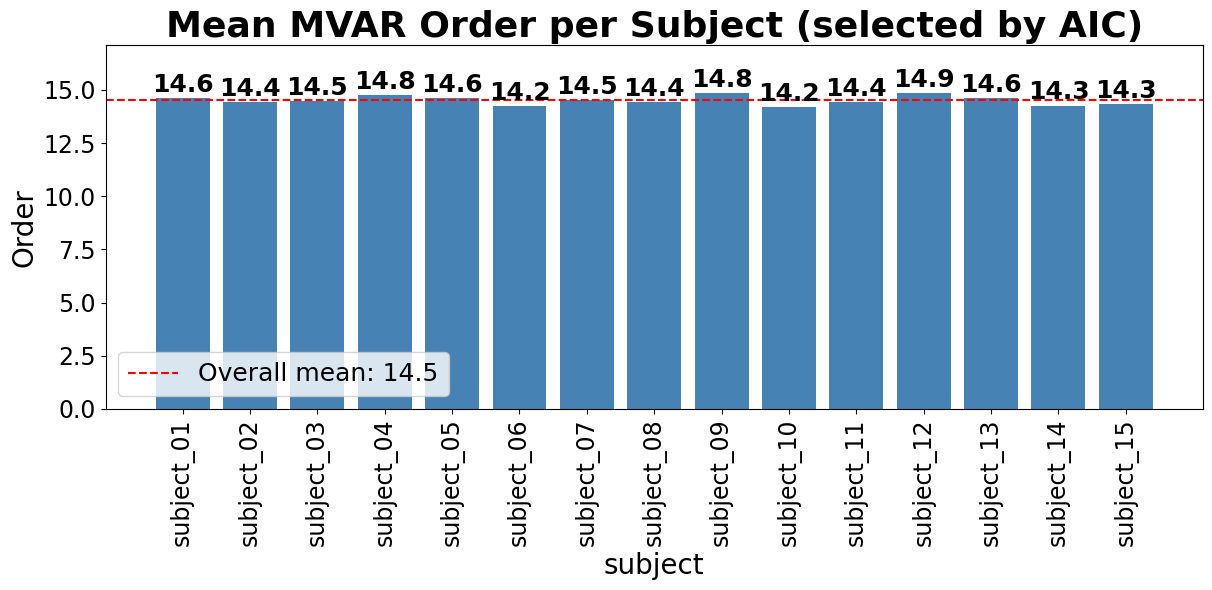

In [48]:
overall_mean = df_order['mean_order'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(per_subject.index, per_subject.values, color='steelblue')
ax.axhline(y=overall_mean, color='red', linestyle='--',
           label=f'Overall mean: {overall_mean:.1f}')
for rect, val in zip(bars, per_subject.values):
    ax.text(rect.get_x() + rect.get_width() / 2, val + 0.05, f'{val:.1f}',
            ha='center', va='bottom', fontsize=18, fontweight='bold')

ax.set_title('Mean MVAR Order per Subject (selected by AIC)', fontsize=26, fontweight='bold')
ax.set_ylabel('Order', fontsize=20)
ax.set_xlabel('subject', fontsize=20)
ax.tick_params(axis='both', labelsize=17)
plt.setp(ax.get_xticklabels(), rotation=90)
ax.set_ylim(0, max(per_subject.values) * 1.15)
ax.legend(fontsize=18)
plt.tight_layout()

out = os.path.join(OUTPUT_DIR, 'figures', 'mvar_order_analysis.png')
os.makedirs(os.path.dirname(out), exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches='tight', facecolor='white')
print('Saved:', out)
